In [1]:
# ==========================================
# Boston House Price Prediction
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving HousingData.csv to HousingData.csv


In [3]:
# Load Dataset

df = pd.read_csv("HousingData.csv")

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (506, 14)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [6]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [8]:
# Fill missing values using median

df.fillna(df.median(numeric_only=True), inplace=True)

# Verify
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [9]:
# Check duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
#if duplicates exist

#df.drop_duplicates(inplace=True)

In [12]:
print(df.shape)

(506, 14)


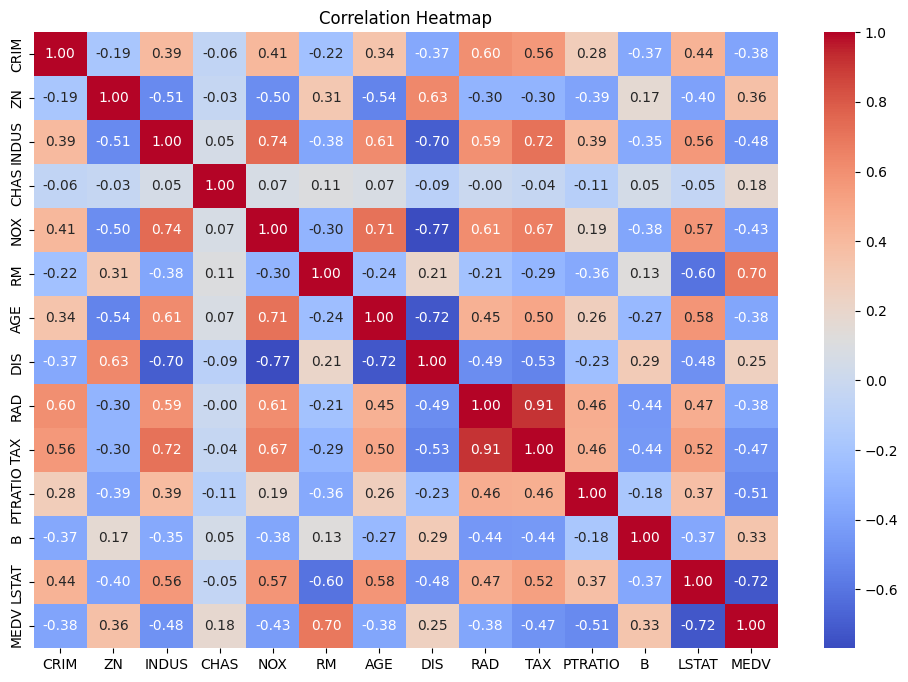

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

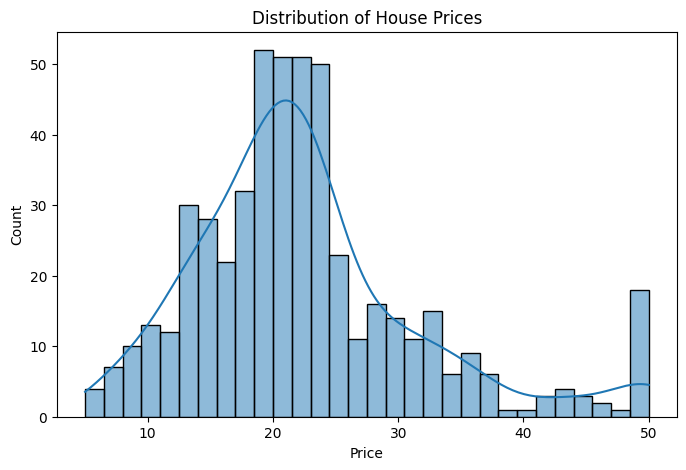

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['MEDV'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

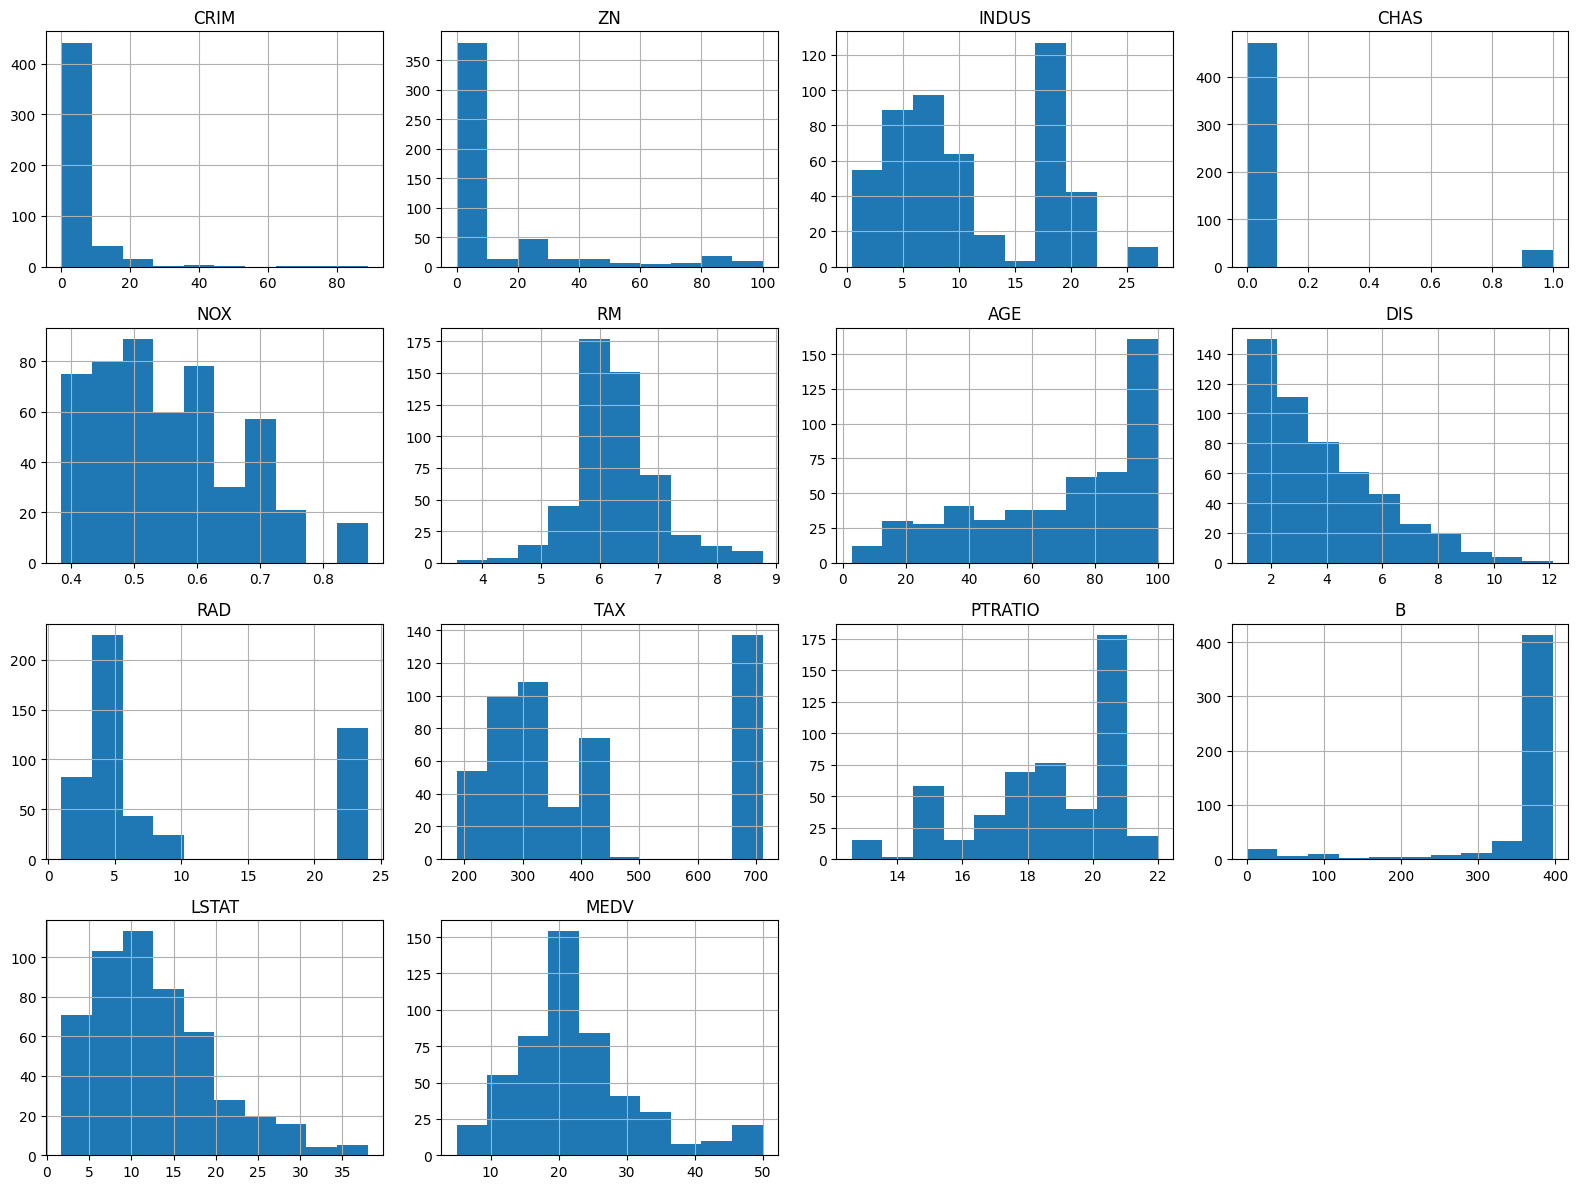

In [15]:
df.hist(figsize=(16,12))

plt.tight_layout()

plt.show()

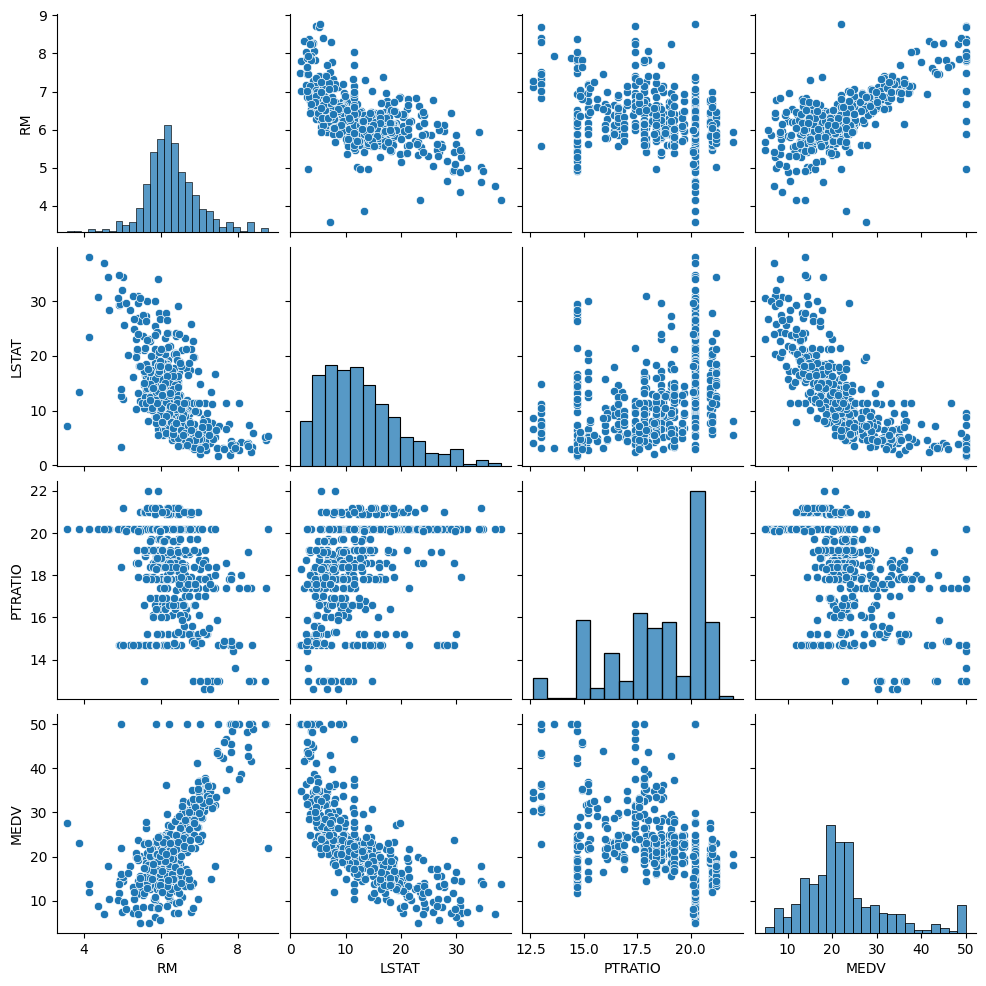

In [16]:
#optional

sns.pairplot(
    df[['RM','LSTAT','PTRATIO','MEDV']]
)

plt.show()

In [20]:
# Features

X = df.drop("MEDV", axis=1)

# Target

y = df["MEDV"]

#split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (404, 13)
Testing Samples : (102, 13)


In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [21]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,2))
print("Mean Squared Error (MSE):", round(mse,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))
print("R2 Score:", round(r2,2))

Mean Absolute Error (MAE): 3.15
Mean Squared Error (MSE): 25.0
Root Mean Squared Error (RMSE): 5.0
R2 Score: 0.66


In [22]:
evaluation = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

evaluation

,Metric,Value
0,MAE,3.148737
1,MSE,24.999385
2,RMSE,4.999938
3,R2 Score,0.659101


In [23]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
173,23.6,29.022908
274,32.4,36.516545
491,13.6,14.539302
72,22.8,25.060058
452,16.1,18.396727
76,20.0,23.028883
316,17.8,17.967158
140,14.0,14.582830
471,19.6,22.082804
500,16.8,20.856181


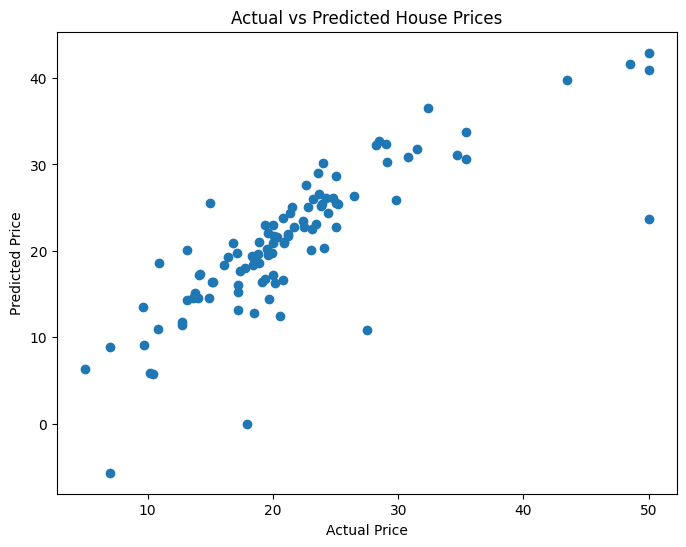

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

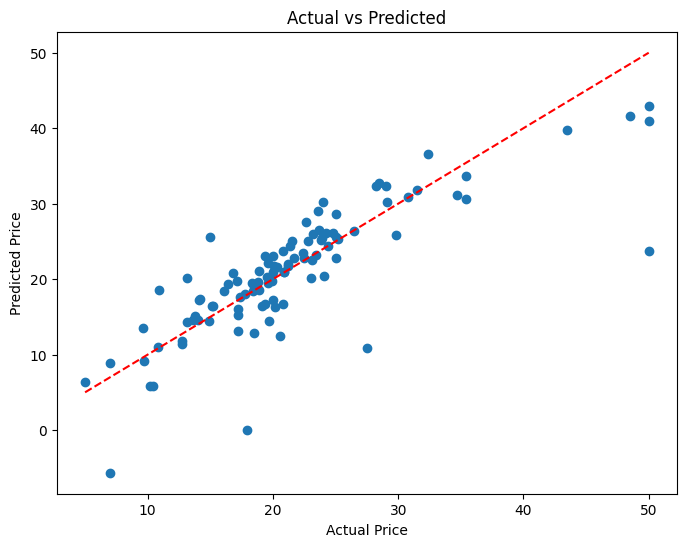

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

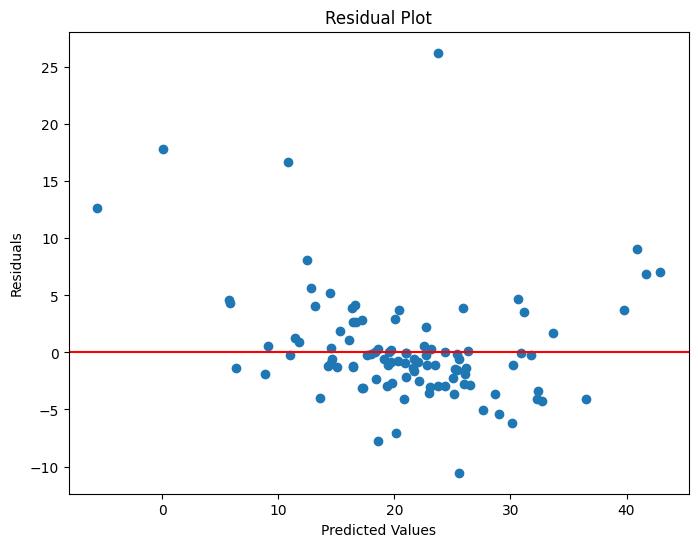

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

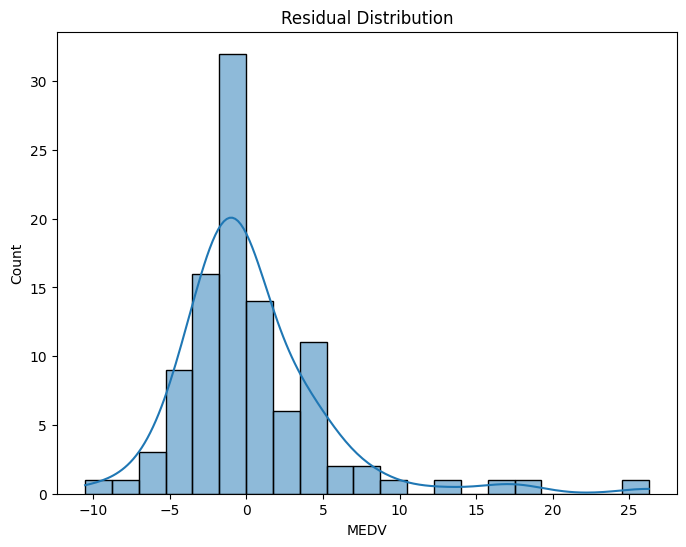

In [27]:
plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

In [28]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
5,RM,4.717140
3,CHAS,3.279482
8,RAD,0.218217
1,ZN,0.028179
11,B,0.012033
9,TAX,-0.009054
6,AGE,-0.018190
2,INDUS,-0.025656
0,CRIM,-0.112574
12,LSTAT,-0.444167


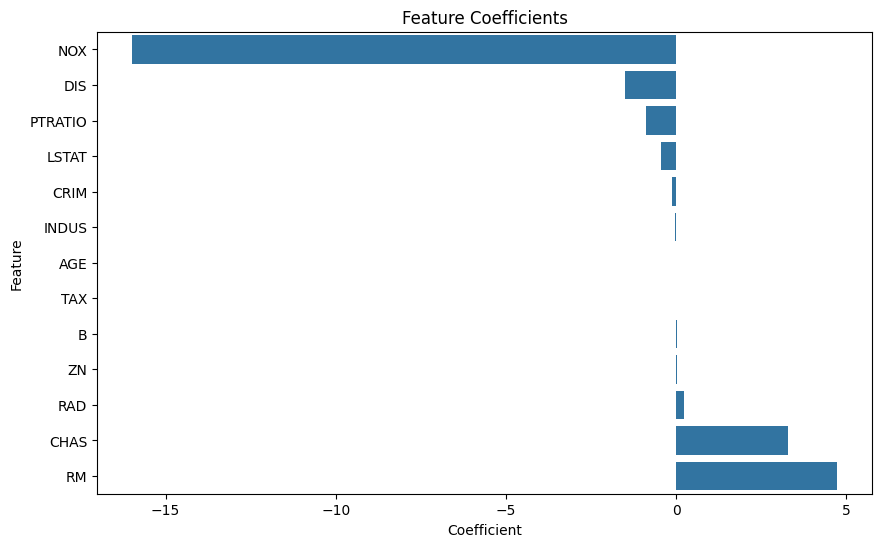

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients.sort_values(by="Coefficient"),
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Coefficients")

plt.show()

In [30]:
sample_house = [[
    0.10,   # CRIM
    18.0,   # ZN
    2.31,   # INDUS
    0,      # CHAS
    0.538,  # NOX
    6.575,  # RM
    65.2,   # AGE
    4.09,   # DIS
    1,      # RAD
    296,    # TAX
    15.3,   # PTRATIO
    396.90, # B
    4.98    # LSTAT
]]

predicted_price = model.predict(sample_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 30.161966227954018


In [31]:
print("="*50)
print("Boston House Price Prediction")
print("="*50)

print("Model Used : Linear Regression")
print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

print()

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,2))

print("="*50)

Boston House Price Prediction
Model Used : Linear Regression
Training Samples : 404
Testing Samples : 102

MAE : 3.15
MSE : 25.0
RMSE : 5.0
R2 Score : 0.66


In [32]:
import joblib

# Save the trained model
joblib.dump(model, "Boston_House_Price_Model.pkl")

print("Model saved successfully!")

loaded_model = joblib.load("Boston_House_Price_Model.pkl")

print("Model loaded successfully!")

loaded_model.predict(sample_house)

Model saved successfully!
Model loaded successfully!


array([30.16196623])

In [33]:
print("="*60)
print("      BOSTON HOUSE PRICE PREDICTION")
print("="*60)

print(f"Dataset Shape       : {df.shape}")
print(f"Training Samples    : {X_train.shape[0]}")
print(f"Testing Samples     : {X_test.shape[0]}")
print(f"Number of Features  : {X.shape[1]}")

print("\nModel Used          : Linear Regression")

print("\nEvaluation Metrics")
print("----------------------")
print(f"MAE       : {mae:.2f}")
print(f"MSE       : {mse:.2f}")
print(f"RMSE      : {rmse:.2f}")
print(f"R2 Score  : {r2:.2f}")

print("="*60)
print("Project Completed Successfully")
print("="*60)

      BOSTON HOUSE PRICE PREDICTION
Dataset Shape       : (506, 14)
Training Samples    : 404
Testing Samples     : 102
Number of Features  : 13

Model Used          : Linear Regression

Evaluation Metrics
----------------------
MAE       : 3.15
MSE       : 25.00
RMSE      : 5.00
R2 Score  : 0.66
Project Completed Successfully


# Conclusion

In this project, a Linear Regression model was developed to predict Boston house prices based on various housing features. The dataset was preprocessed by handling missing values, followed by exploratory data analysis to understand feature relationships. The dataset was split into training and testing sets, and the model was trained using the training data. Performance was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. The results indicate that the model is capable of predicting house prices with reasonable accuracy. This project demonstrates the complete workflow of a supervised machine learning regression problem using Python and Scikit-learn.

In [34]:
!git clone https://github.com/shivakumar-28/ShadowFox.git

Cloning into 'ShadowFox'...


In [35]:
!ls

Boston_House_Price_Model.pkl  HousingData.csv  sample_data  ShadowFox


In [36]:
!ls ShadowFox

In [37]:
!cp HousingData.csv ShadowFox/

In [38]:
!cp Boston_House_Price_Model.pkl ShadowFox/

In [39]:
!ls *.ipynb

ls: cannot access '*.ipynb': No such file or directory
